
# 1D Nonlinear Heat Conduction: Theory and FEM Solver
This notebook explores the 1D steady-state heat conduction equation with a temperature-dependent thermal conductivity. We will cover the mathematical formulation, derive the analytical solution, and solve the system using the Finite Element Method (FEM).


## 1. Mathematical Formulation
The governing equation for 1D steady-state conduction (with no internal heat generation) is given by:

$$\frac{d}{dx} \left[ k(T) \frac{dT}{dx} \right] = 0$$

We assume a nonlinear thermal conductivity $k$ that depends linearly on the temperature $T$:

$$k(T) = k_0(1 + \beta T)$$

The specific boundary conditions for our domain $x \in [0, L]$ are Dirichlet constraints:
* **Left Boundary ($x=0$):** $T = T_L$
* **Right Boundary ($x=L$):** $T = T_R$

### 2. Analytical Solution
By integrating the governing equation twice and applying the boundary conditions, we can find the exact temperature profile.

Integrating once gives a constant heat flux:
$$k_0(1 + \beta T) \frac{dT}{dx} = C_1$$

Integrating a second time with respect to $x$:
$$k_0 \left( T + \frac{1}{2}\beta T^2 \right) = C_1 x + C_2$$

Applying $T(0) = 0$ yields $C_2 = 0$. Applying $T(L) = T_R$ gives the constant $C_1$:
$$C_1 = \frac{k_0(T_R + 0.5\beta T_R^2)}{L}$$

Solving the quadratic equation for $T(x)$, we obtain the analytical solution:
$$T(x) = \frac{-1 + \sqrt{1 + 2\beta M(x)}}{\beta}$$
Where $M(x) = \frac{(T_R + 0.5\beta T_R^2)}{L}x$.

### 3. Finite Element Method (FEM) Approach
The FEM approach utilizes the **Galerkin Method** with linear elements. Due to the nonlinear conductivity $k(T)$, the resulting global system is nonlinear and is solved using the **Newton-Raphson** iterative scheme.

For each element, we use 2-Point Gauss Quadrature to integrate the element stiffness matrix $\mathbf{k}_e$ and the residual vector $\mathbf{r}_e$. The local contributions are then assembled into the global stiffness matrix $\mathbf{K}$ and global residual vector $\mathbf{R}$ to solve for the temperature updates $\Delta\mathbf{T}$:

$$\mathbf{K} \Delta\mathbf{T} = -\mathbf{R}$$

 Iter         ||R||
--------------------
    0     2.179e-01
    1     2.971e-02
    2     2.313e-04
    3     8.990e-09

Converged in 3 iterations.


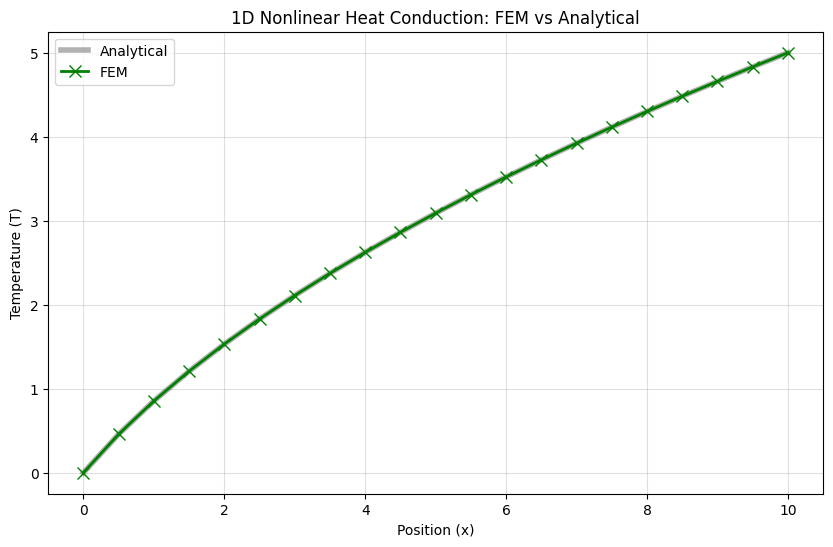

In [19]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)  # needed for float64 precision in Newton-Raphson

# --- 1. Parameters & Boundary Conditions ---
L          = 10.0
T_LEFT     = 0.0   # NOTE: analytical solution assumes T_LEFT = 0
T_RIGHT    = 5.0
K0         = 1.0
BETA       = 0.4
N_ELEMENTS = 20

# --- 2. FEM Solver (pure JAX) ---
def solve_fem(n_elements, L, T_L, T_R, k0, beta):
    assert T_L == 0.0, "Analytical comparison requires T_LEFT = 0 (see derivation)"

    n_nodes = n_elements + 1
    le      = L / n_elements
    x       = jnp.linspace(0.0, L, n_nodes)
    T       = jnp.linspace(T_L, T_R, n_nodes)  # linear initial guess

    tol, max_iter = 1e-8, 25
    converged = False

    # Gauss points in reference element [-1, 1]
    gauss_pts = jnp.array([-1.0 / jnp.sqrt(3.0), 1.0 / jnp.sqrt(3.0)])

    print(f"{'Iter':>5}  {'||R||':>12}")
    print("-" * 20)

    for iteration in range(max_iter):
        K_global = jnp.zeros((n_nodes, n_nodes))
        R_global = jnp.zeros(n_nodes)

        for e in range(n_elements):
            nodes = jnp.array([e, e + 1])
            ke    = jnp.zeros((2, 2))
            re    = jnp.zeros(2)

            for xi in gauss_pts:
                N = jnp.array([0.5 * (1 - xi), 0.5 * (1 + xi)])  # shape functions
                B = jnp.array([-1.0, 1.0]) / le                   # dN/dx

                T_gp    = N @ T[nodes]           # temperature at Gauss point
                k       = k0 * (1.0 + beta * T_gp)
                T_prime = B @ T[nodes]           # dT/dx at Gauss point

                # Residual: r_e = ∫ B^T k(T) T' dΩ
                re += k * T_prime * B * (le / 2.0)

                # Tangent stiffness: K = ∫ B^T k B dΩ  +  ∫ B^T (k0 β T') N dΩ
                ke += (k * jnp.outer(B, B)
                       + k0 * beta * T_prime * jnp.outer(B, N)) * (le / 2.0)

            # Assemble into global arrays using index_add
            K_global = K_global.at[jnp.ix_(nodes, nodes)].add(ke)
            R_global = R_global.at[nodes].add(re)

        # Free (interior) DOFs
        free     = jnp.arange(1, n_nodes - 1)
        res_norm = jnp.linalg.norm(R_global[free])
        print(f"{iteration:>5}  {float(res_norm):>12.3e}")

        if res_norm < tol:
            print(f"\nConverged in {iteration} iterations.")
            converged = True
            break

        # Newton-Raphson update: ΔT = -K^{-1} R
        K_free = K_global[jnp.ix_(free, free)]
        R_free = R_global[free]
        T = T.at[free].add(jnp.linalg.solve(K_free, -R_free))

    if not converged:
        print(f"\nWarning: Newton-Raphson did not converge in {max_iter} iterations.")

    return x, T

# --- 3. Execution ---
x_fem, T_fem = solve_fem(N_ELEMENTS, L, T_LEFT, T_RIGHT, K0, BETA)

# --- 4. Analytical Solution (valid for T_LEFT = 0) ---
# k0(T + β/2 T²) = C1·x  →  C1 = (T_R + β/2 T_R²) / L  (k0 cancels)
C1           = (T_RIGHT + 0.5 * BETA * T_RIGHT**2) / L
T_analytical = (-1.0 + jnp.sqrt(1.0 + 2.0 * BETA * C1 * x_fem)) / BETA

# --- 5. Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(x_fem, T_analytical, 'k-',  label='Analytical', linewidth=4, alpha=0.3)
plt.plot(x_fem, T_fem,        'g-x', label='FEM',        markersize=8, linewidth=2)
plt.title("1D Nonlinear Heat Conduction: FEM vs Analytical")
plt.xlabel("Position (x)")
plt.ylabel("Temperature (T)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()